In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [134]:
df = pd.read_csv("Cancer_Data.csv")

## EDA

In [135]:
df.head(15)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750,NaN


In [136]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

#### creating X dataframe without id feature and full NaN feature

#### as target feature is not numeric, we can avoid separating it now (it will help us to check and delete outliers in more optimal way) 

In [148]:
X = df.drop(columns=['id', 'Unnamed: 32'])

In [ ]:
from itertools import combinations

def correlation_calc(df, method='spearman'):
    """
    Calculate correlations for all numeric column pairs and return a sorted report.
    
    Parameters:
    - df: pandas DataFrame
    - method: 'pearson', 'spearman', or 'kendall'
    - threshold: optional minimum absolute correlation to include
    
    Returns:
    - DataFrame with sorted correlation pairs
    """
    numeric_df = df.select_dtypes(include=[np.number])
    
    columns = numeric_df.columns.tolist()
    pairs = list(combinations(columns, 2))
    
    results = []
    for col1, col2 in pairs:
        corr = numeric_df[col1].corr(numeric_df[col2], method=method)
        results.append({
            'Column 1': col1,
            'Column 2': col2,
            'Correlation': corr,
            'Abs Correlation': abs(corr)
        })
    
    report = pd.DataFrame(results)
    report = report.sort_values('Abs Correlation', ascending=False).reset_index(drop=True)
    
    return report[['Column 1', 'Column 2', 'Correlation']]

In [150]:
correlations = (correlation_calc(X))

In [151]:
print(f"{correlations.sort_index()}")

                   Column 1              Column 2  Correlation
0               radius_mean             area_mean     0.999602
1              radius_worst            area_worst     0.998891
2               radius_mean        perimeter_mean     0.997802
3            perimeter_mean             area_mean     0.997068
4              radius_worst       perimeter_worst     0.993548
..                      ...                   ...          ...
430            texture_mean           symmetry_se     0.008945
431     concave points_mean            texture_se     0.008710
432             radius_mean  fractal_dimension_se    -0.008411
433    fractal_dimension_se            area_worst     0.007312
434  fractal_dimension_mean             radius_se     0.001477

[435 rows x 3 columns]


#### dropping highly correlated features (>=0.8)

In [ ]:
#Drop one feature from each highly correlated pair

threshold = 0.8
corr_matrix = X.corr(numeric_only=True).abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
X = X.drop(columns=to_drop)

not the most optimal and correct approach

from every pair we delete second one, which is giving more 'importance' to first one without reason

need to be improved

In [204]:
def check_outlier(df,col):
    """
    Print sorted, max, min and mean of column, to find outliers easier

    Args:
        df (pd.DataFrame): The name of DataFrame
        col (str): The name of column
        
    Returns:
        List: [sorted_values(list),max_value,min_value,mean_value]
    """
    sorted_column = df[col].sort_values().tolist()
    max_column = df[col].max()
    min_column = df[col].min()
    mean_column = df[col].mean()
    print(f"{col} -> max: {max_column}, min: {min_column}, mean: {mean_column}")
    return [sorted_column,max_column,min_column,mean_column]
    

#### helps to understand distributions of the rest features


In [205]:
for i in X.columns:
    if(i == 'diagnosis'):
        continue
    check_outlier(X, i)

radius_mean -> max: 27.22, min: 6.981, mean: 14.084937388193202
texture_mean -> max: 33.81, min: 9.71, mean: 19.2349373881932
smoothness_mean -> max: 0.1447, min: 0.05263, mean: 0.09604468694096602
compactness_mean -> max: 0.3114, min: 0.01938, mean: 0.10285756708407873
symmetry_mean -> max: 0.304, min: 0.106, mean: 0.1805937388193202
fractal_dimension_mean -> max: 0.09575, min: 0.04996, mean: 0.0626034168157424
radius_se -> max: 1.509, min: 0.1115, mean: 0.39491484794275494
texture_se -> max: 3.896, min: 0.3602, mean: 1.2044570661896243
smoothness_se -> max: 0.02333, min: 0.002667, mean: 0.00697549373881932
compactness_se -> max: 0.1064, min: 0.002252, mean: 0.02482263864042934
concave points_se -> max: 0.0409, min: 0.0, mean: 0.011597516994633274
symmetry_se -> max: 0.06146, min: 0.007882, mean: 0.020216776386404293
symmetry_worst -> max: 0.5774, min: 0.1565, mean: 0.28917459749552776


In [ ]:
X_old = X.drop(columns=['diagnosis'])

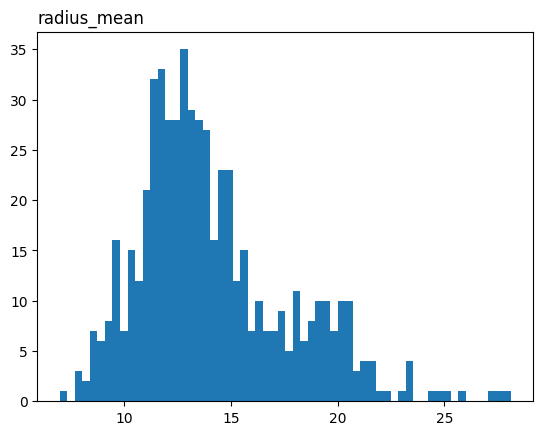

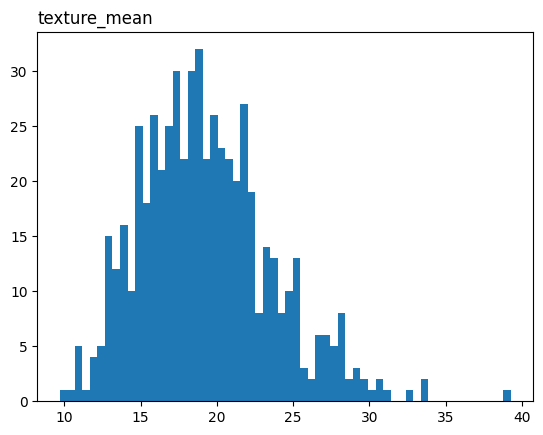

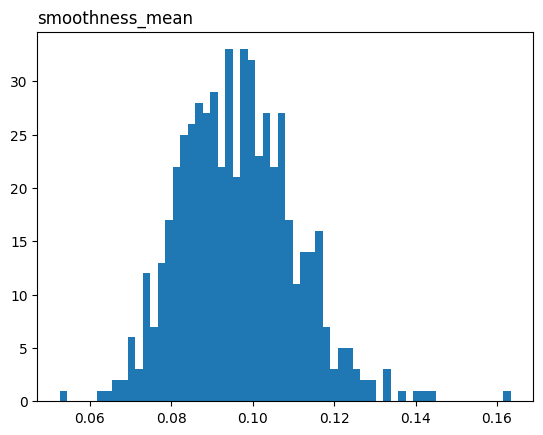

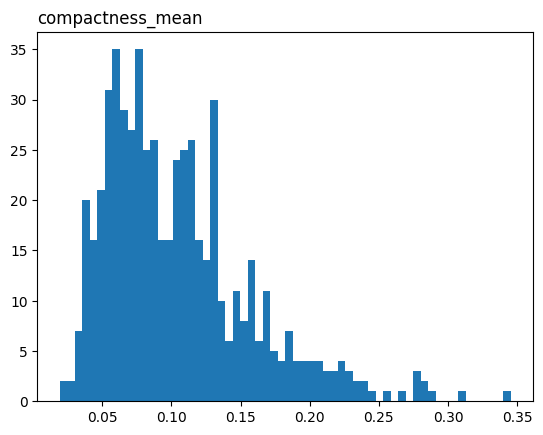

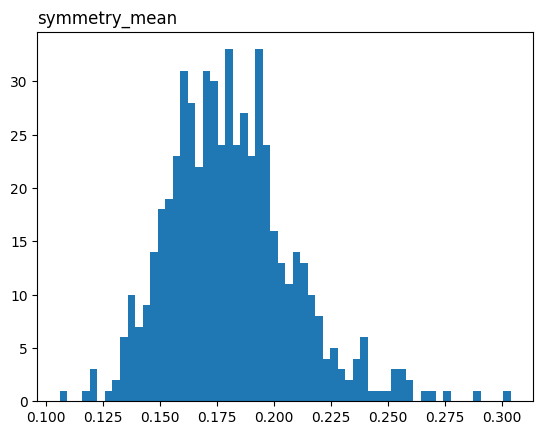

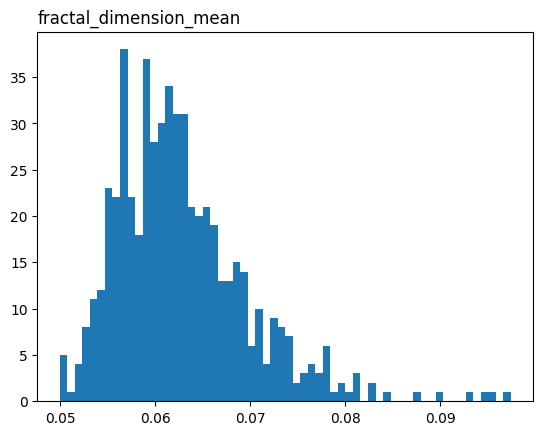

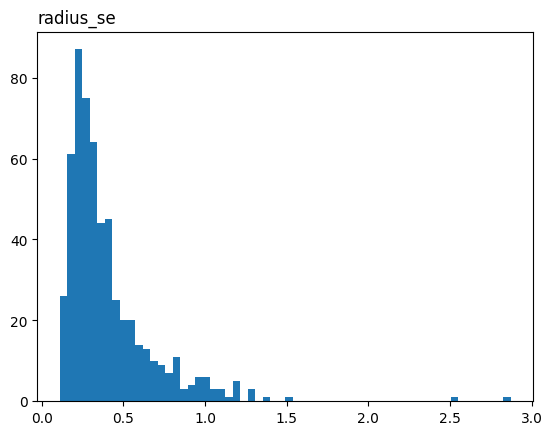

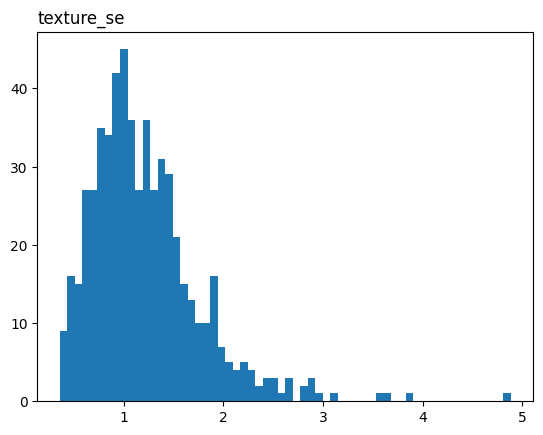

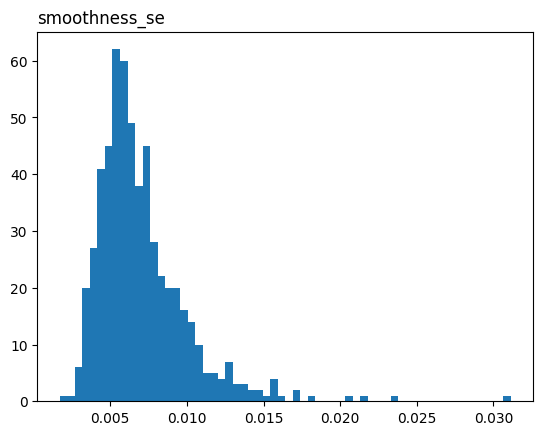

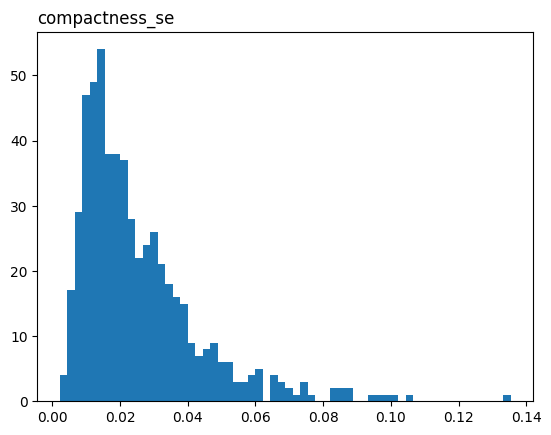

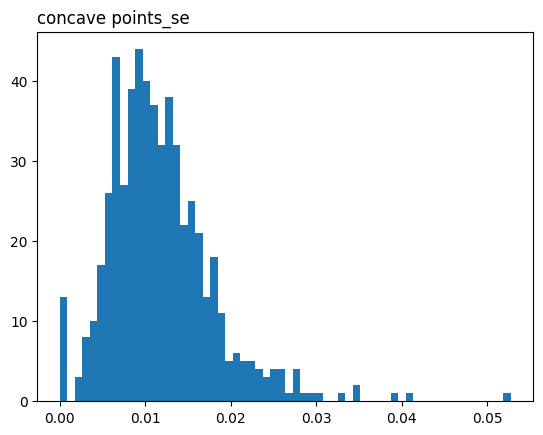

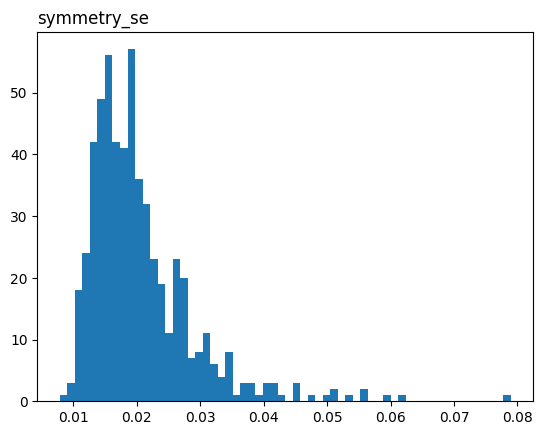

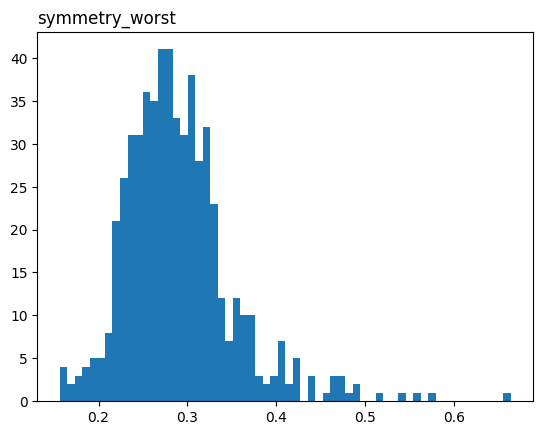

In [ ]:
for col in X_old.columns:
    
    plt.hist(X_old[col], bins=60)
    plt.title(col, loc='left')
    
    plt.show()

#### let's analyze features one by one (according to histograms)
#### as features are not so many, we will do it manually instead of IQR


In [160]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   diagnosis               569 non-null    object 
 1   radius_mean             569 non-null    float64
 2   texture_mean            569 non-null    float64
 3   smoothness_mean         569 non-null    float64
 4   compactness_mean        569 non-null    float64
 5   symmetry_mean           569 non-null    float64
 6   fractal_dimension_mean  569 non-null    float64
 7   radius_se               569 non-null    float64
 8   texture_se              569 non-null    float64
 9   smoothness_se           569 non-null    float64
 10  compactness_se          569 non-null    float64
 11  concave points_se       569 non-null    float64
 12  symmetry_se             569 non-null    float64
 13  symmetry_worst          569 non-null    float64
dtypes: float64(13), object(1)
memory usage: 62

In [161]:
print(X['texture_mean'].sort_values())

166     9.71
0      10.38
313    10.72
120    10.82
123    10.89
       ...  
265    31.12
219    32.47
259    33.56
232    33.81
239    39.28
Name: texture_mean, Length: 569, dtype: float64


In [162]:
X = X.drop(X['texture_mean'].idxmax())

In [163]:
print(X['smoothness_mean'].sort_values())

568    0.05263
178    0.06251
270    0.06429
298    0.06576
450    0.06613
        ...   
520    0.13710
105    0.13980
3      0.14250
122    0.14470
504    0.16340
Name: smoothness_mean, Length: 568, dtype: float64


In [164]:
X = X.drop(X['smoothness_mean'].idxmax())

In [168]:
print(X['radius_se'].sort_values())

376    0.1115
547    0.1144
241    0.1153
527    0.1166
412    0.1186
        ...  
258    1.2920
138    1.2960
417    1.3700
122    1.5090
461    2.5470
Name: radius_se, Length: 566, dtype: float64


In [169]:
X = X.drop(X['radius_se'].idxmax())

In [170]:
print(X['texture_se'].sort_values())

313    0.3602
205    0.3621
209    0.3628
484    0.3871
347    0.3981
        ...  
122    3.1200
12     3.5680
473    3.6470
561    3.8960
192    4.8850
Name: texture_se, Length: 565, dtype: float64


In [171]:
X = X.drop(X['texture_se'].idxmax())

In [172]:
print(X['smoothness_se'].sort_values())

489    0.002667
263    0.002826
149    0.002838
186    0.002866
403    0.002887
         ...   
116    0.018350
314    0.020750
505    0.021770
122    0.023330
213    0.031130
Name: smoothness_se, Length: 564, dtype: float64


In [173]:
X = X.drop(X['smoothness_se'].idxmax())

In [174]:
print(X['compactness_se'].sort_values())

178    0.002252
315    0.003012
270    0.003710
308    0.003746
568    0.004660
         ...   
152    0.095860
122    0.098060
42     0.100600
290    0.106400
190    0.135400
Name: compactness_se, Length: 563, dtype: float64


In [175]:
X = X.drop(X['compactness_se'].idxmax())

In [176]:
print(X['concave points_se'].sort_values())

568    0.00000
538    0.00000
550    0.00000
473    0.00000
391    0.00000
        ...   
68     0.03322
389    0.03441
288    0.03487
12     0.04090
152    0.05279
Name: concave points_se, Length: 562, dtype: float64


In [177]:
X = X.drop(X['concave points_se'].idxmax())

In [178]:
print(X['symmetry_se'].sort_values())

38     0.007882
209    0.009539
259    0.009947
263    0.010130
449    0.010290
         ...   
351    0.055430
146    0.056280
3      0.059630
314    0.061460
78     0.078950
Name: symmetry_se, Length: 561, dtype: float64


In [179]:
X = X.drop(X['symmetry_se'].idxmax())

In [180]:
print(X['symmetry_worst'].sort_values())

38     0.1565
561    0.1566
116    0.1652
136    0.1712
491    0.1783
        ...  
35     0.4863
119    0.4882
323    0.5558
146    0.5774
3      0.6638
Name: symmetry_worst, Length: 560, dtype: float64


In [181]:
X = X.drop(X['symmetry_worst'].idxmax())

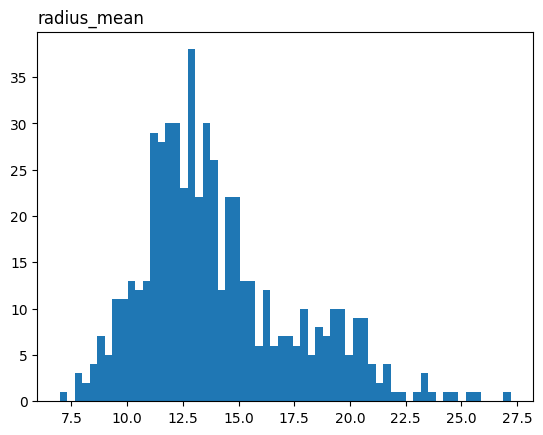

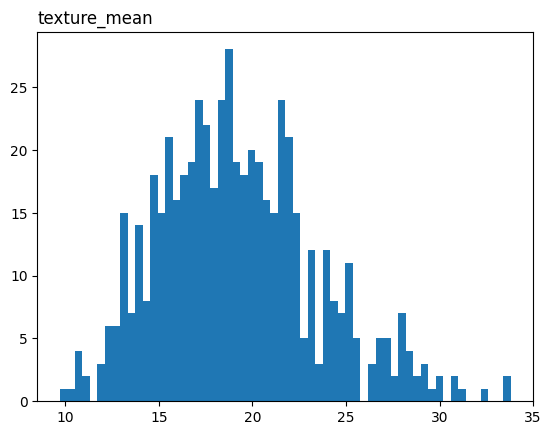

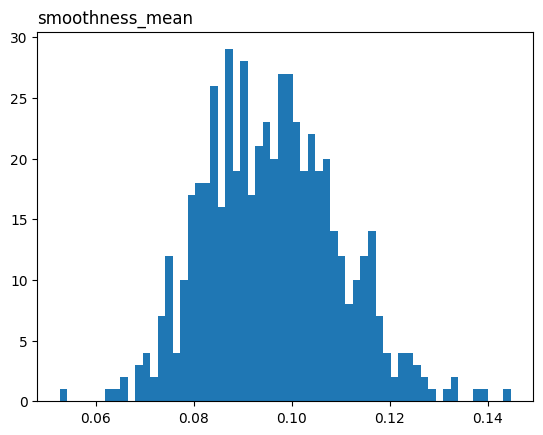

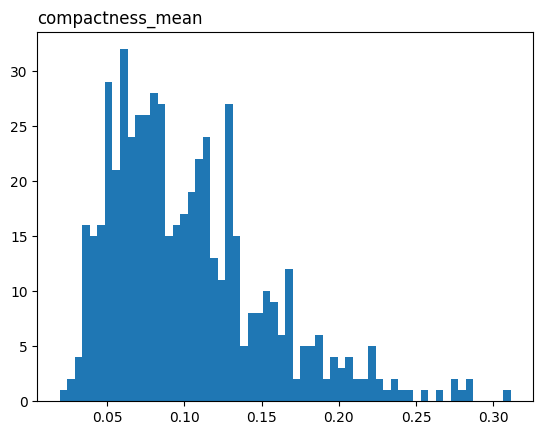

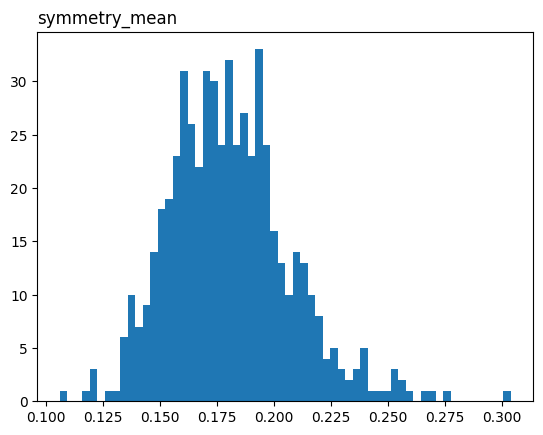

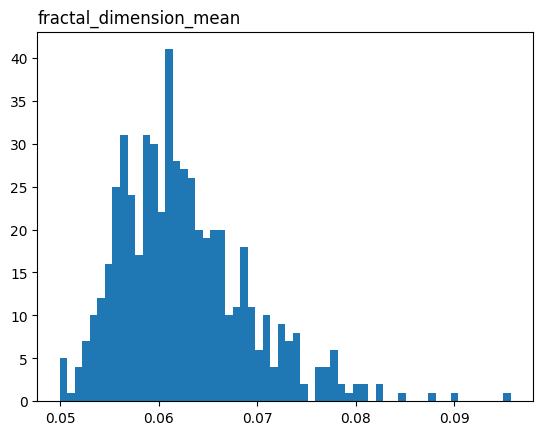

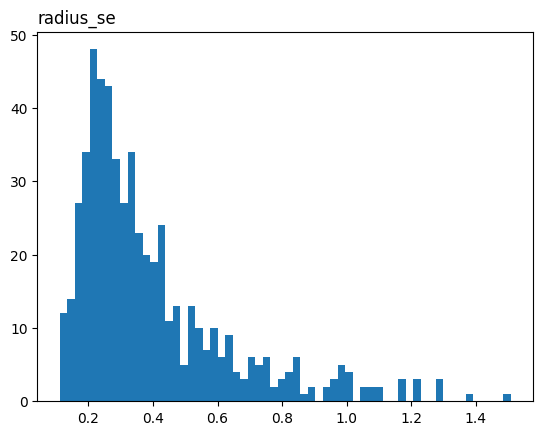

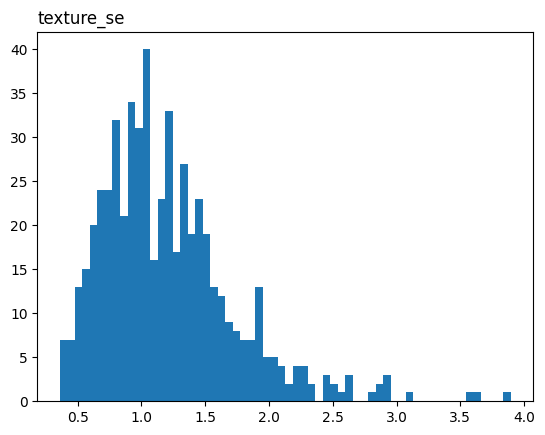

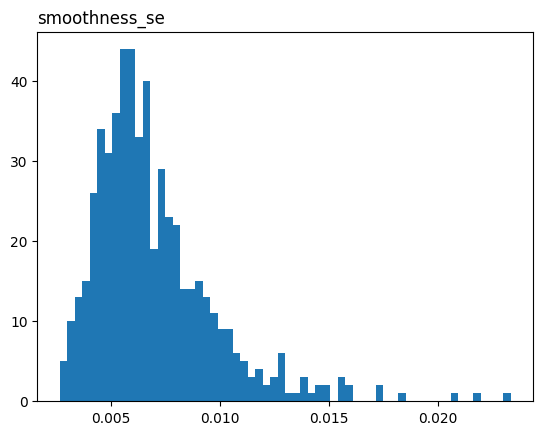

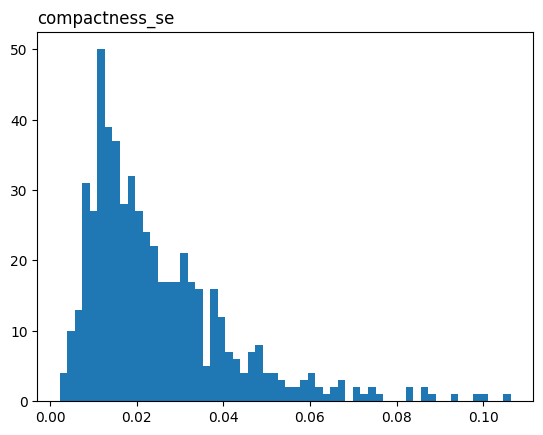

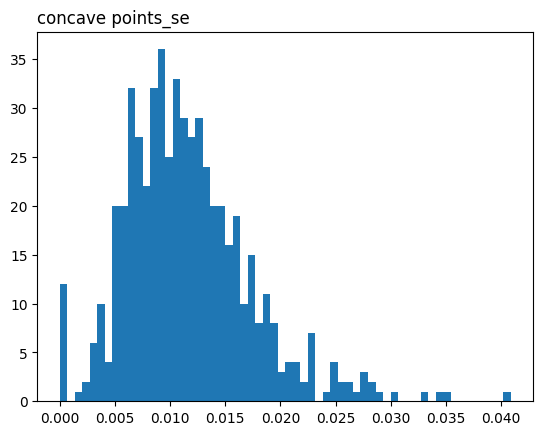

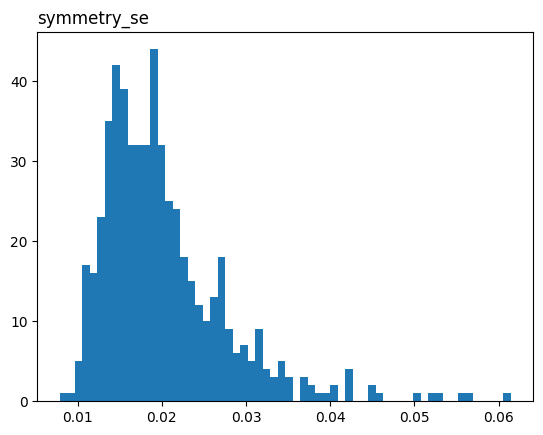

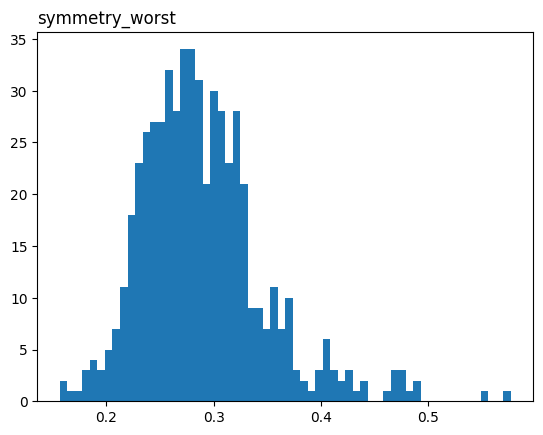

In [183]:
for col in X.columns:
    if (col == 'diagnosis'):
        continue
    plt.hist(X[col], bins=60)
    plt.title(col, loc='left')
    
    plt.show()

#### now we can compare histograms X_old and X

### we are taking first 6 components because they map around 80% of information

In [ ]:
sc = MinMaxScaler()
final_X = X.drop(columns='diagnosis')
final_X = sc.fit_transform(final_X)
pca = PCA(n_components=6)
final_X = pd.DataFrame(pca.fit_transform(final_X))
print(pca.explained_variance_ratio_)


# we find optimal components using it like TOP-P sampling

[0.3685395  0.17716181 0.1325921  0.08238798 0.07209686 0.05876475]


#### now we separate target from others

In [190]:
y = X['diagnosis']

In [193]:
X = X.drop(columns='diagnosis')

In [194]:
print(X.shape,y.shape)

(559, 13) (559,)


## Model selection

#### cross-validation

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)

history = {k: [] for k in range(1, 21)}  

for train_index, test_index in skf.split(X, y):
    x_train_fold, x_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    scaler = MinMaxScaler()
    x_train_fold = scaler.fit_transform(x_train_fold)
    x_test_fold = scaler.transform(x_test_fold)
    
    pca = PCA(n_components=6)
    x_train_fold = pca.fit_transform(x_train_fold)
    x_test_fold = pca.transform(x_test_fold)
    

    for k in range(1, 21):
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(x_train_fold, y_train_fold)
        y_hat = model.predict(x_test_fold)
        acc = accuracy_score(y_test_fold, y_hat)
        history[k].append(acc)


mean_acc = {k: sum(history[k])/len(history[k]) for k in history}


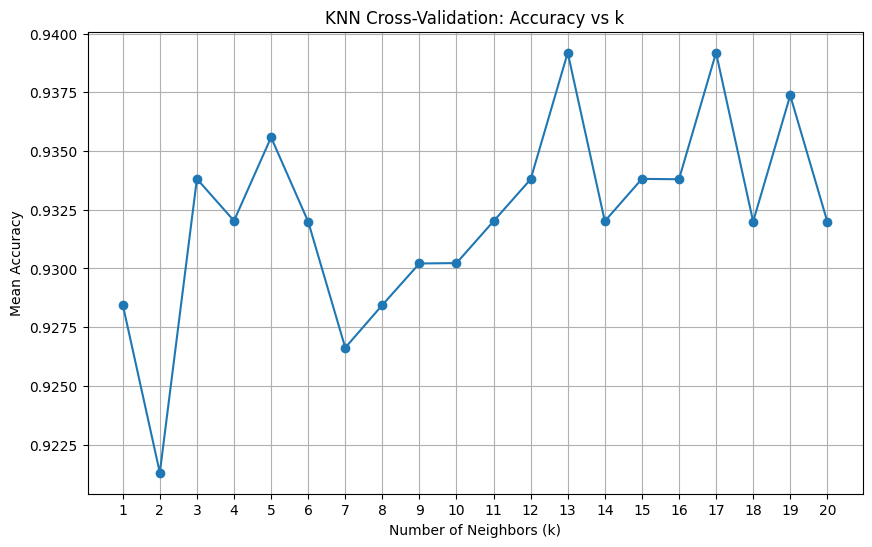

In [ ]:

plt.figure(figsize=(10, 6))
plt.plot(list(mean_acc.keys()), list(mean_acc.values()), marker='o')
plt.xticks(range(1, 21))
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Accuracy')
plt.title('KNN Cross-Validation: Accuracy vs k')
plt.grid(True)
plt.show()

### choosing best model and evaluating on whole test set

In [197]:
best_k = max(mean_acc, key = mean_acc.get)
best_acc = mean_acc[best_k]

print(f"Best model's K: {best_k} ||||||||||| accuracy {best_acc:.3f}") 

Best model's K: 13 ||||||||||| accuracy 0.939


##### then we will see that it is not the best one :)

#### as we get similar results on range of k (5,19) odd numbers, let's compute them on whole test set, for choosing best one

## Evaluate 

In [ ]:
X_train, X_test, Y_train,Y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=32)

In [ ]:
scaler_final = MinMaxScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

pca_final = PCA(n_components=6)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)


for final_k in range(5,20,2):
    final_model = KNeighborsClassifier(n_neighbors=final_k)
    final_model.fit(X_train_pca,Y_train)
    final_Y_hat = final_model.predict(X_test_pca)
    final_model_acc = accuracy_score(Y_test, final_Y_hat)
    print(f"{final_k}: {final_model_acc}")
    # print(precision_score(Y_test, final_Y_hat, pos_label='M'))
    # print(recall_score(Y_test,final_Y_hat, pos_label='M'))
    #print(f1_score(Y_test,final_Y_hat, pos_label='M'))
    print(confusion_matrix(Y_test,final_Y_hat))





5: 0.9642857142857143
[[71  0]
 [ 4 37]]
7: 0.9285714285714286
[[71  0]
 [ 8 33]]
9: 0.9285714285714286
[[71  0]
 [ 8 33]]
11: 0.9196428571428571
[[71  0]
 [ 9 32]]
13: 0.9196428571428571
[[71  0]
 [ 9 32]]
15: 0.9285714285714286
[[71  0]
 [ 8 33]]
17: 0.9285714285714286
[[71  0]
 [ 8 33]]
19: 0.9196428571428571
[[71  0]
 [ 9 32]]


### we find that best one is 5, filtering them on stratifiedfold validation, then testing best ones on whole test set 

##### lets compute other metrics for our final model

In [ ]:
final_model = KNeighborsClassifier(n_neighbors=5)
final_model.fit(X_train_pca, Y_train)
final_Y_hat = final_model.predict(X_test_pca)

prec_score = precision_score(Y_test, final_Y_hat, pos_label='M')
rec_score = recall_score(Y_test,final_Y_hat, pos_label='M')
f1 = f1_score(Y_test,final_Y_hat, pos_label='M')
conf_mat = confusion_matrix(Y_test,final_Y_hat)


print(f"precision: {prec_score:.3f}")
print(f"recall: {rec_score:.3f}")
print(f"f1_score: {f1:.3f}")
print(f"{conf_mat}")



precision: 1.000
recall: 0.902
f1_score: 0.949
[[71  0]
 [ 4 37]]
